In [1]:
import pandas as pd

In [ ]:
messages = pd.read_csv('SMSSpamCollection.txt', sep='\t', names=['label', 'message'])
messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [49]:
messages.describe()

,label,message,message_cleaning
count,5572,5572,5572
unique,2,5169,5058
top,ham,"Sorry, I'll call later",sorry call later
freq,4825,30,30


In [3]:
import re
from nltk.corpus import stopwords

In [27]:
def cleaning(message):
    m = re.sub('[^a-zA-Z]', ' ', message)
    m = m.lower()
    m = m.split()
    m = [word for word in m if not word in stopwords.words('english')]
    m = ' '.join(m)
    return m

In [28]:
m = "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
cleaning(m)

'go jurong point crazy available bugis n great world la e buffet cine got amore wat'

In [29]:
messages['message_cleaning'] = messages['message'].apply(cleaning)
messages.head()

,label,message,message_cleaning
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though


In [66]:
messages.shape

(5572, 3)

In [31]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

In [34]:
X = cv.fit_transform(messages['message_cleaning']).toarray()
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5572, 7623))

In [35]:
cv.vocabulary_

{'go': 2643,
 'jurong': 3411,
 'point': 4928,
 'crazy': 1425,
 'available': 450,
 'bugis': 871,
 'great': 2723,
 'world': 7454,
 'la': 3532,
 'buffet': 869,
 'cine': 1154,
 'got': 2684,
 'amore': 220,
 'wat': 7243,
 'ok': 4532,
 'lar': 3565,
 'joking': 3379,
 'wif': 7358,
 'oni': 4559,
 'free': 2450,
 'entry': 2040,
 'wkly': 7413,
 'comp': 1268,
 'win': 7370,
 'fa': 2176,
 'cup': 1485,
 'final': 2298,
 'tkts': 6741,
 'st': 6207,
 'may': 3971,
 'text': 6604,
 'receive': 5316,
 'question': 5210,
 'std': 6249,
 'txt': 6929,
 'rate': 5262,
 'apply': 305,
 'dun': 1893,
 'say': 5653,
 'early': 1913,
 'hor': 3002,
 'already': 193,
 'nah': 4280,
 'think': 6657,
 'goes': 2649,
 'usf': 7064,
 'lives': 3721,
 'around': 356,
 'though': 6677,
 'freemsg': 2456,
 'hey': 2920,
 'darling': 1541,
 'week': 7289,
 'word': 7445,
 'back': 491,
 'like': 3672,
 'fun': 2513,
 'still': 6272,
 'tb': 6537,
 'xxx': 7527,
 'chgs': 1108,
 'send': 5745,
 'rcv': 5275,
 'even': 2089,
 'brother': 841,
 'speak': 6128,
 '

In [38]:
y = pd.get_dummies(messages['label'])
y

,ham,spam
0,True,False
1,True,False
2,False,True
3,True,False
4,True,False
...,...,...
5567,False,True
5568,True,False
5569,True,False
5570,True,False


In [42]:
y = y.iloc[:, 0].values
y

array([ True,  True, False, ...,  True,  True,  True], shape=(5572,))

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)

In [45]:
from sklearn.naive_bayes import MultinomialNB

spam_model = MultinomialNB()
spam_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [47]:
y_pred = spam_model.predict(X_test)
y_pred

array([ True,  True,  True, ...,  True,  True,  True], shape=(1115,))

In [48]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.979372197309417

In [50]:
y_pred_train = spam_model.predict(X_train)

In [51]:
accuracy_score(y_train, y_pred_train)

0.9930446488669509

In [52]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.89      0.95      0.92       136
        True       0.99      0.98      0.99       979

    accuracy                           0.98      1115
   macro avg       0.94      0.97      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[129   7]
 [ 16 963]]


In [64]:
import matplotlib.pyplot as plt

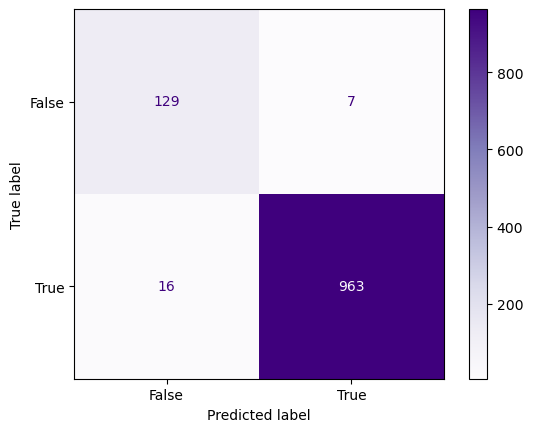

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
    display_labels=spam_model.classes_)

disp.plot(cmap="Purples")
plt.show()